In [3]:
# This is a more complete version of Effiencies.py
# This code is for making and testing the solar panel model based on NOAA gml spo irradiance data
# https://gml.noaa.gov/aftp/data/radiation/baseline/spo
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin

# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

In [4]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))
    
    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    #diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time

In [5]:
# import panel data function
def Import_Panel_Data(year, day):
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    date = file_103['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep = NumberDate <= int(input_2)
    file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    time_103 = file_103['Time']
    voltage_103 = file_103['V'] 
    current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    power_103 = voltage_103 * current_103
    # -----------------------------

    # print(f'len(power_101) = {len(power_101)}')
    return power_101, power_103, time_101, time_103

In [6]:
year = 25
day  = '345'

Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
power_101_og, power_103_og, __, __ = Import_Panel_Data(year, day)
# not using 103 but just in case:
power_103 = power_103_og
# get the time_101 from day 345 because it is complete
__,__,time_101,__ = Import_Panel_Data(25,365)
print(len(time_101))


power_101_og = power_101_og.to_numpy()
print(f'og: {len(power_101_og)}')
# print(len(power_101))
# if power_101 is too small, we pad with nan
if len(power_101_og) <= 2880:
    difference = 2880 - len(power_101_og)
    power_101 = power_101_og
    for i in np.arange(0,difference,1):
        power_101 = np.append(power_101, np.nan)
print(len(power_101))
print(Direct_Irradiance)



https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat
2880
og: 2879
2880
660    1046.3
661    1046.4
662    1046.6
663    1046.7
664    1046.8
        ...  
655    1045.2
656    1045.1
657    1045.1
658    1045.1
659    1045.1
Name: 12, Length: 1440, dtype: float64


In [7]:
print(len(time_101))
print(time_101)


2880
0       00:00:30
1       00:01:00
2       00:01:30
3       00:02:00
4       00:02:30
          ...   
2875    23:58:00
2876    23:58:30
2877    23:59:00
2878    23:59:30
2879    23:59:30
Name: Time, Length: 2880, dtype: str


2880
2880


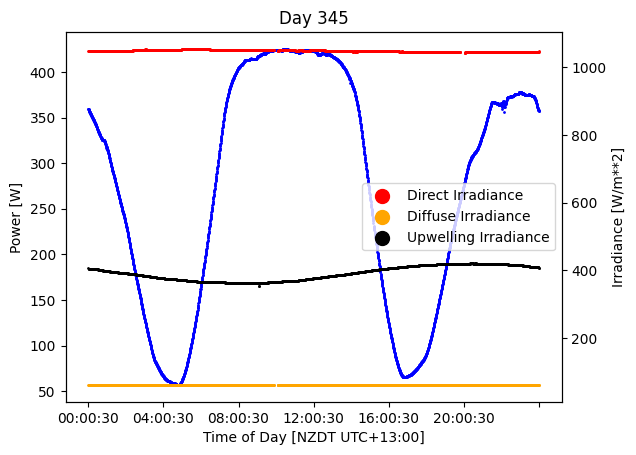

In [8]:
# plot our data

print(len(power_101))
print(len(time_101))
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, color = 'blue', label = 'Power_101', s = 1)

ax2 = ax1.twinx()
ax2.set_ylabel('Irradiance [W/m**2]')
ax2.scatter(NOAA_time, Direct_Irradiance, color = 'red', label = 'Direct Irradiance', s = 1)
ax2.scatter(NOAA_time, Diffuse_Irradiance, color = 'orange', label = 'Diffuse Irradiance', s = 1)
ax2.scatter(NOAA_time, Upwelling_Irradiance, color = 'black', label = 'Upwelling Irradiance', s = 1)
ax2.legend(markerscale = 10)

ax1.set_xticks(np.linspace(0, len(time_101), 7))
ax1.set_title(f'Day {day}')
plt.show()

In [9]:
# Make a model for power data using irradiance

# use sigmoids for smooth transition from front to back of panel
def sigmoid(x, sharpness, shift):
    return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
 

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness):
    eff_direct = effs[0]
    eff_diffuse = effs[1]
    eff_upwelling = effs[2]
    efficiency_back = .7

    Change_Time_1 = 280
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back

    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_diffuse*Diffuse_Irradiance + eff_upwelling*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power

    

In [10]:
# we want to fit the efficiencies
Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
def Fit_Model(time, eff_dir, eff_diff, eff_upwelling, sharpness):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_diff ,eff_upwelling]
    sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50)
    sim_power_2880 = np.repeat(sim_power, 2)
    if len(sim_power_2880) > len(power_101_og):
        sim_power_data_length = sim_power_2880[:len(power_101_og)]
        # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
        nanmask = ~np.isnan(power_101_og)
        # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
        sim_power_2880 = sim_power_data_length[nanmask]
    return sim_power_2880


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat


In [11]:

print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01,.07, 50]) # using the diff and upwelling from edges
print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=.3)     
params['eff_diff'].set(min=0, max=.3)
params['eff_upwelling'].set(min=0, max=.3)
params['sharpness'].set(min = 1, max = 100)

nanmask = ~np.isnan(power_101_og)

DayArrayPowerLength = len(power_101_og[nanmask])
x = np.arange(0,DayArrayPowerLength,1)

# remove the nan values from power_101
y = power_101_og[nanmask]
print(f'y = {len(y)}')

result = mod.fit(y, params, time=x, method='leastsq', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")

fitted_dir_eff = result.params['eff_dir'].value
fitted_diff_eff = result.params['eff_diff'].value
fitted_upwelling_eff = result.params['eff_upwelling'].value
fitted_sharpness = result.params['sharpness'].value


print()
print()
# print(f'fitted_dir_eff = {fitted_dir_eff}')
# print(f'fitted_diff_eff = {fitted_diff_eff}')
# print(f'fitted_upwelling_eff = {fitted_upwelling_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

print(fit_report(result))

2880
 - Adding parameter "eff_dir"
 - Adding parameter "eff_diff"
 - Adding parameter "eff_upwelling"
 - Adding parameter "sharpness"
['eff_dir', 'eff_diff', 'eff_upwelling', 'sharpness'] ['time']
y = 2879


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 69
    # data points      = 2833
    # variables        = 4
    chi-square         = 1281085.64
    reduced chi-square = 452.840452
    Akaike info crit   = 17329.3216
    Bayesian info crit = 17353.1180
    R-squared          = nan
##  Warning: uncertainties could not be estimated:
    sharpness:      at initial value
    sharpness:      at boundary
[[Variables]]
    eff_dir:        0.22786714 (init = 0)
    eff_diff:       0.29999058 (init = 0)
    eff_upwelling:  0.01836014 (init = 0)
    sharpness:      1.00000000 (init = 1)


len(time_101) = 2880
len(simulation_101) = 2880


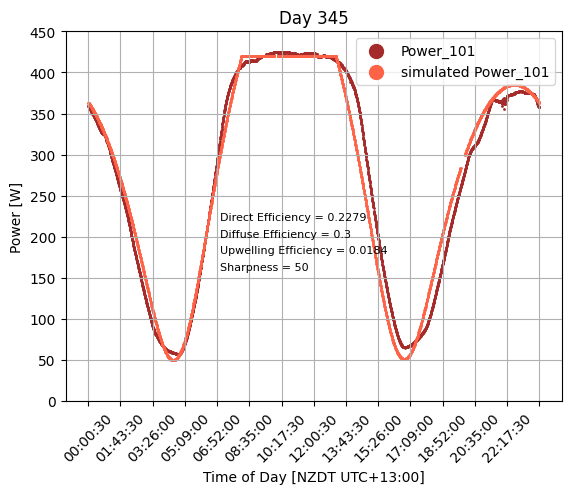

In [12]:
eff_direct = fitted_dir_eff
eff_diffuse = fitted_diff_eff
eff_upwelling = fitted_upwelling_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_diffuse = .01
# eff_upwelling = .07
sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_diffuse, eff_upwelling], sharpness),2)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
print(f'len(time_101) = {len(time_101)}')
print(f'len(simulation_101) = {len(simulation_101)}')
ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')

ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Diffuse Efficiency = {np.round(eff_diffuse, 4)}', fontsize = 8)
ax1.text(840,220-40,f'Upwelling Efficiency = {np.round(eff_upwelling, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [13]:
# 2 component fit + 1 sharpness

# Make a model for power data using irradiance

# use sigmoids for smooth transition from front to back of panel
def sigmoid(x, sharpness, shift):
    return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
 

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness):
    eff_direct = effs[0]
    eff_isotropic = effs[1]
    efficiency_back = .7

    Change_Time_1 = 280
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back

    
    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power

# we want to fit the efficiencies and the sharpness
Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
def Fit_Model(time, eff_dir, eff_isotropic, sharpness):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_isotropic]
    sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50)
    sim_power_2880 = np.repeat(sim_power, 2)
    if len(sim_power_2880) > len(power_101_og):
        sim_power_data_length = sim_power_2880[:len(power_101_og)]
        # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
        nanmask = ~np.isnan(power_101_og)
        # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
        sim_power_2880 = sim_power_data_length[nanmask]
    return sim_power_2880


print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01, 50]) # using the diff and upwelling from edges
print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=1)     
params['eff_isotropic'].set(min=0, max=1)
params['sharpness'].set(value = 50, min = .1, max = 100)

nanmask = ~np.isnan(power_101_og)

DayArrayPowerLength = len(power_101_og[nanmask])
x = np.arange(0,DayArrayPowerLength,1)

# remove the nan values from power_101
y = power_101_og[nanmask]

print(f'len(x) = {len(x)}')
print(f'len(y) = {len(y)}')


result = mod.fit(y, params, time=x, method='nelder', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")


fitted_dir_eff = result.params['eff_dir'].value
fitted_isotropic_eff = result.params['eff_isotropic'].value
fitted_sharpness = result.params['sharpness'].value


print()
print()
# print(f'fitted_dir_eff = {fitted_dir_eff}')
# print(f'fitted_isotropic_eff = {fitted_isotropic_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

print(fit_report(result))

https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat
2880
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
['eff_dir', 'eff_isotropic', 'sharpness'] ['time']
len(x) = 2879
len(y) = 2879


[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 167
    # data points      = 2833
    # variables        = 3
    chi-square         = 1322941.04
    reduced chi-square = 467.470333
    Akaike info crit   = 17418.4010
    Bayesian info crit = 17436.2483
    R-squared          = nan
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    eff_dir:        0.22728883 (init = 0)
    eff_isotropic:  0.0

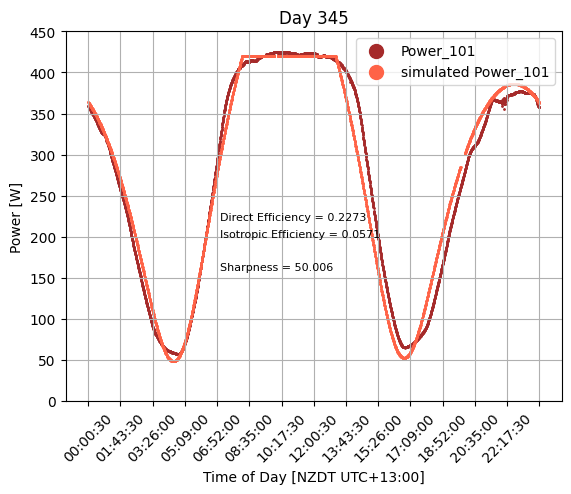

In [14]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
# sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Isotropic Efficiency = {np.round(eff_isotropic, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [15]:
# Now let us try not fitting for the efficiencies but calculating them from the extreama of the panel
# This code does not work for cloudy days, not really possible to do I think
power_101_numpy = power_101
# plt.plot(power_101_numpy[500+75+3:500+75+6])
print(f'power_101_numpy[579] = {power_101_numpy[579]}')
print()

side = np.argmin(power_101)
print(f'side = {side}')
isotropic_power = power_101_numpy[side]
# plt.plot(power_101_numpy[2500:-1])
all_comp_power = power_101_numpy[2500+250]
print(f'all_comp_power = {all_comp_power}')
print()
direct_power = all_comp_power/.7 - isotropic_power
print(f'direct_power = {direct_power}')
print()
# direct_irradiance is reletivly constant
Direct_Irradiance_instance = Direct_Irradiance[.5*(2500+250)]
print(f'Direct_Irradiance_instance = {Direct_Irradiance_instance}')
print()

Isotropic_Irradiance_instance = Diffuse_Irradiance[int(.5*(side))] + Upwelling_Irradiance[int(.5*(side))]
print(f'Isotropic_Irradiance_instance = {Isotropic_Irradiance_instance}')
print()
# power = Irradiance * eff * area
# eff = power / (Irradiance* area)
area = 2
Direct_eff_calc = direct_power / (Direct_Irradiance_instance * area)
print(f'Direct_eff_calc = {Direct_eff_calc}')
print()

Isotropic_eff_calc = isotropic_power / (Isotropic_Irradiance_instance* area)
print(f'Isotropic_eff_calc = {Isotropic_eff_calc}')

power_101_numpy[579] = 56.755255555555564

side = 2879
all_comp_power = 377.5137580246911

direct_power = nan

Direct_Irradiance_instance = 1049.7

Isotropic_Irradiance_instance = 445.6

Direct_eff_calc = nan

Isotropic_eff_calc = nan


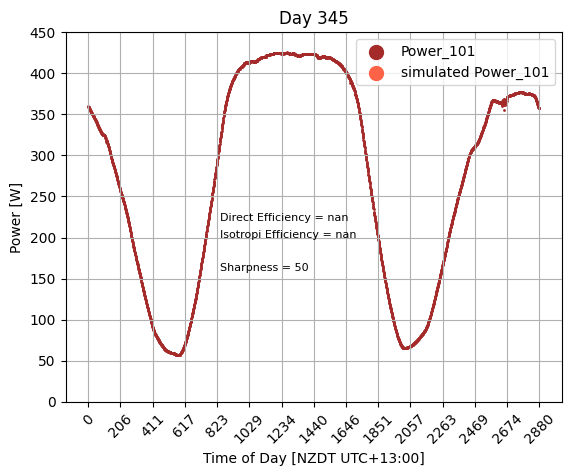

In [16]:
# eff_direct = fitted_dir_eff
# eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

eff_direct = Direct_eff_calc
eff_isotropic = Isotropic_eff_calc
sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2)
time_101_numeric = np.arange(len(time_101))
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101_numeric, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
ax1.scatter(time_101_numeric, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Isotropi Efficiency = {np.round(eff_isotropic, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [17]:
# lets understand the relationship between the direct, diffuse and upwelling irradiance
# fig, ax1 = plt.subplots()
# ax1.plot(time_101, np.repeat(Direct_Irradiance,2)[:-1])
# ax1.plot(time_101, np.repeat(Diffuse_Irradiance,2)[:-1])
# ax1.plot(time_101, np.repeat(Upwelling_Irradiance,2)[:-1])
# ax1.set_xticks(np.linspace(0, len(time_101), 15))
# ax1.tick_params(axis='x', labelrotation=45)
# ax1.set_title(f'Day {day}')
# plt.show()


# fig, ax1 = plt.subplots()
# ax1.plot(time_101, np.repeat(Direct_Irradiance - np.mean(Direct_Irradiance) - Upwelling_Irradiance + np.mean(Upwelling_Irradiance),2)[:-1])
# ax1.plot(time_101, np.repeat(Direct_Irradiance - np.mean(Direct_Irradiance) - Diffuse_Irradiance + np.mean(Diffuse_Irradiance),2)[:-1])
# ax1.set_xticks(np.linspace(0, len(time_101), 15))
# ax1.tick_params(axis='x', labelrotation=45)
# ax1.set_title(f'Day {day}')
# plt.show()


In [18]:
# Lets simulate mutliple panels with different angles with this model

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness, angle_negative):
    '''
    This model function is like the old one but lets you put in the angle of the solar panel
    '''
    eff_direct = effs[0]
    eff_isotropic = effs[1]
    efficiency_back = .7

    # The angle the math uses to calculate is not the angle which makes sens for us to define our panel angle as so I correct for it as such
    angle = 360 - angle_negative
    Change_Time_1 = angle/360*1440
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Tertiary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1-2*Change_Time_1+2*Change_Time_2)*sigmoid(-time, sharpness, Change_Time_2-(-2*Change_Time_1+2*Change_Time_2))
    Tertiary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2+4*Change_Time_2-4*Change_Time_1)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1-(+4*Change_Time_2-4*Change_Time_1))
    # Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back + Tertiary_Back + Tertiary_Front
    
    
    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power



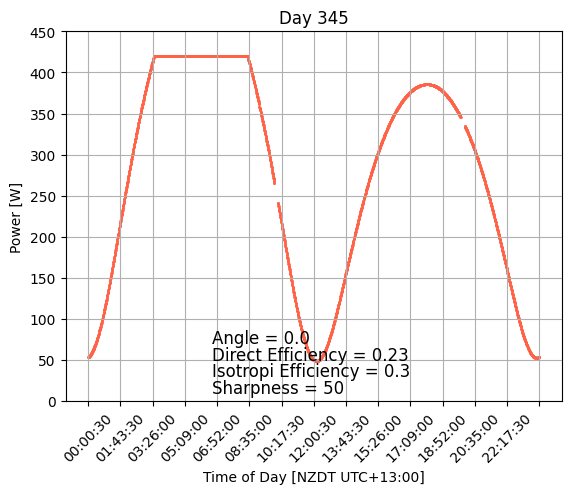

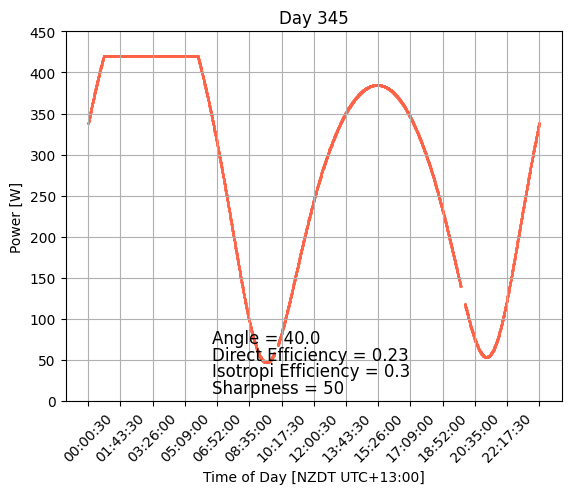

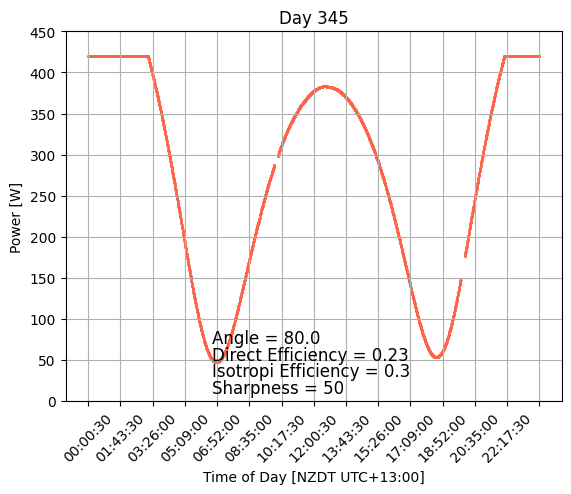

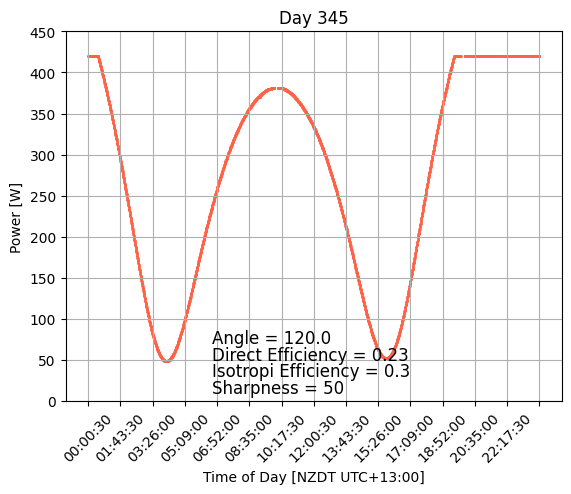

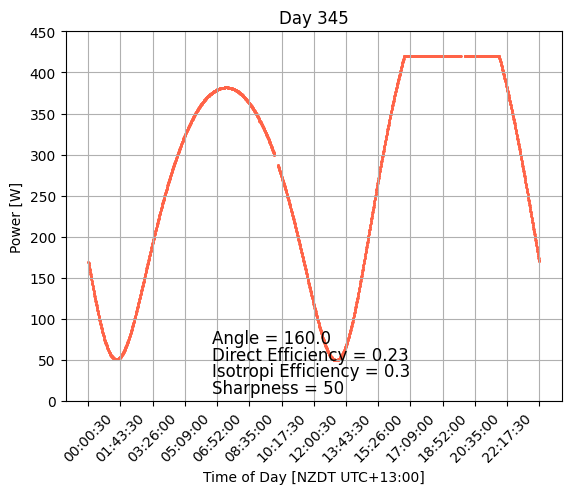

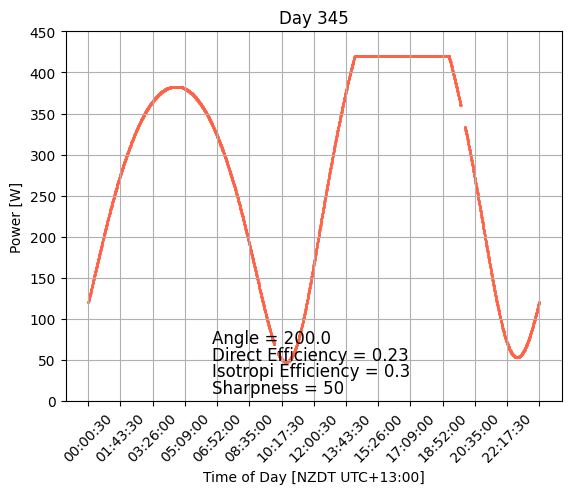

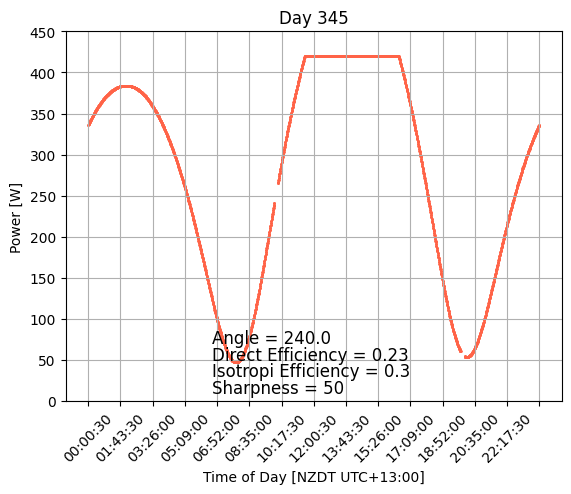

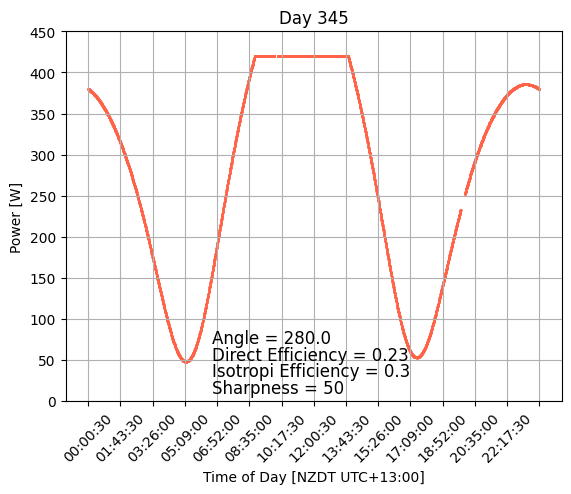

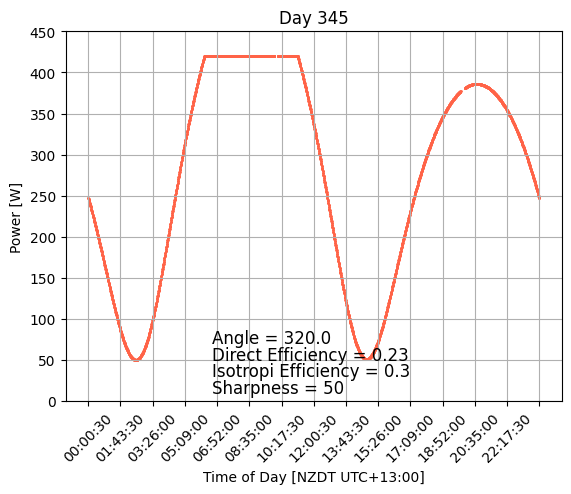

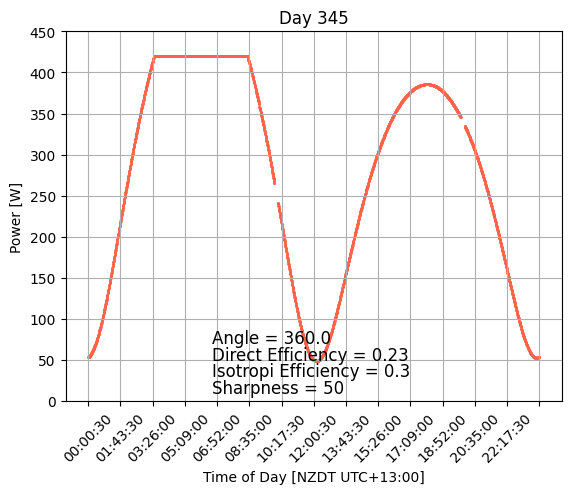

In [19]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50



# ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
for angle in np.linspace(0,360,10):
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
    ax1.set_ylabel('Power [W]')
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle),2)
    ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
    ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
    
    ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
    ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
    ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)
    # ax1.legend(markerscale = 10)
    ax1.set_ylim(0,450)
    ax1.set_xticks(np.linspace(0, len(time_101), 15))
    ax1.set_title(f'Day {day}')
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid('on')
    plt.show()

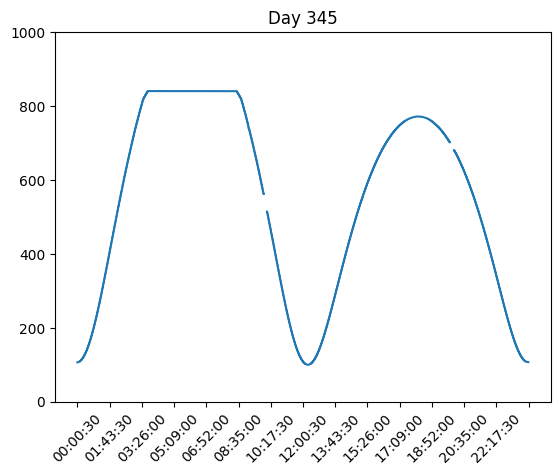

In [20]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

fig, ax = plt.subplots()

simulation_101_0 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2)
x = time_101
line, = ax.plot(x, np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2))
ax.set_xticks(np.linspace(0, len(time_101), 15))
ax.set_title(f'Day {day}')
ax.tick_params(axis='x', labelrotation=45)
ax.set_ylim(0, 1000)
angles = np.linspace(0,360*2,100)
def animate(i):
    # convert i to angle
    angle = angles[i]
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle),2)
    combined = simulation_101 + simulation_101_0
    line.set_ydata(combined)
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, save_count=50)

# To save the animation, use e.g.
#
ani.save("movie.mp4")
#
# or
#
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

plt.show()

0.2272888275093839
0.05707936785663853


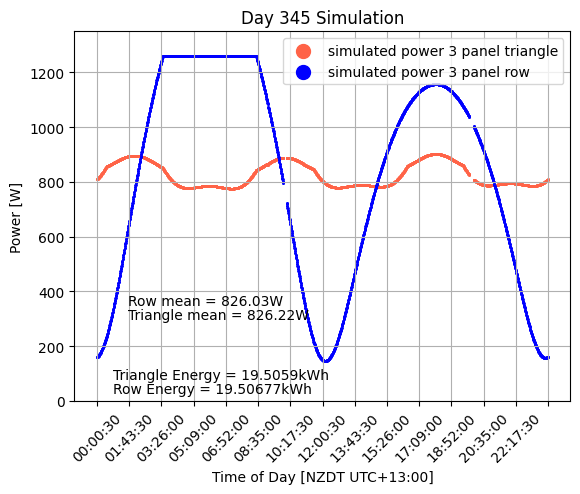

In [21]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50

print(eff_direct)
print(eff_isotropic)


# ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
angle_1 = 0
angle_2 = 120
angle_3 = 240
simulation_101_1 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_1),2)
simulation_101_2 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_2),2)
simulation_101_3 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_3),2)

simulation_101_Triangle = simulation_101_1 + simulation_101_2 + simulation_101_3
ax1.scatter(time_101, simulation_101_Triangle, color = 'tomato', s = 1, label = 'simulated power 3 panel triangle')
simulation_101_Row = simulation_101_1*3
ax1.scatter(time_101, simulation_101_1*3, color = 'blue', s = 1, label = 'simulated power 3 panel row')

# ax1.scatter(time_101, simulation_101_1, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_2, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_3, color = 'tomato', s = 1, label = 'simulated Power_101')

# ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
# ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
# ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
# ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450*3)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day} Simulation')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')

# calculate the integrated power (energy) of each array design:

Integrated_Simulation_101_Triangle = trapezoid(np.nan_to_num(simulation_101_Triangle,nan = 0),dx=30)
Integrated_Simulation_101_Triangle_kWh = Integrated_Simulation_101_Triangle/(1000*60**2)
# print(f'Integrated_Simulation_101_Triangle_kwh = {Integrated_Simulation_101_Triangle_kwh}')
plt.text(100, 80, f'Triangle Energy = {np.round(Integrated_Simulation_101_Triangle_kWh,5)}kWh')

Integrated_Simulation_101_Row = trapezoid(np.nan_to_num(simulation_101_Row,nan = 0),dx=30)
Integrated_Simulation_101_Row_kWh = Integrated_Simulation_101_Row/(1000*60**2)
# print(f'Integrated_Simulation_101_Triangle_kwh = {Integrated_Simulation_101_Triangle_kwh}')
plt.text(100, 30, f'Row Energy = {np.round(Integrated_Simulation_101_Row_kWh,5)}kWh')

# Calculate the mean power output:
simulation_triangle_mean = np.nanmean(simulation_101_Triangle)
simulation_row_mean = np.nanmean(simulation_101_Row)

plt.text(200, 300, f'Triangle mean = {np.round(simulation_triangle_mean,2)}W')

plt.text(200, 350, f'Row mean = {np.round(simulation_row_mean,2)}W')


plt.show()




# fig, ax1 = plt.subplots()
# ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
# ax1.set_ylabel('Power [W]')

# # Simulate Triangle

# angle_1 = 0
# angle_2 = 120
# angle_3 = 240
# simulation_101_1 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_1),2)
# simulation_101_2 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_2),2)
# simulation_101_3 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_3),2)

# simulation_101_Triangle = simulation_101_1 + simulation_101_2 + simulation_101_3
# ax1.scatter(time_101, simulation_101_Triangle, color = 'tomato', s = 1, label = 'simulated power 3 panel triangle normalized')

# # Simulate orthognal
# angle_1 = 0
# angle_2 = 90
# simulation_101_1 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_1),2)
# simulation_101_2 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_2),2)
# simulation_101_Orthogonal = simulation_101_1 + simulation_101_2 
# ax1.scatter(time_101, simulation_101_Orthogonal, color = 'blue', s = 1, label = 'simulated power 3 panel orthogonal normalized')
# # ax1.scatter(time_101, simulation_101_1, color = 'tomato', s = 1, label = 'simulated Power_101')
# # ax1.scatter(time_101, simulation_101_2, color = 'tomato', s = 1, label = 'simulated Power_101')
# # ax1.scatter(time_101, simulation_101_3, color = 'tomato', s = 1, label = 'simulated Power_101')

# # ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
# # ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
# # ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
# # ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)
# ax1.legend(markerscale = 10)
# ax1.set_ylim(0,450*3)
# ax1.set_xticks(np.linspace(0, len(time_101), 15))
# ax1.set_title(f'Day {day}')
# ax1.tick_params(axis='x', labelrotation=45)
# ax1.grid('on')
# plt.show()

0.2272888275093839
0.05707936785663853


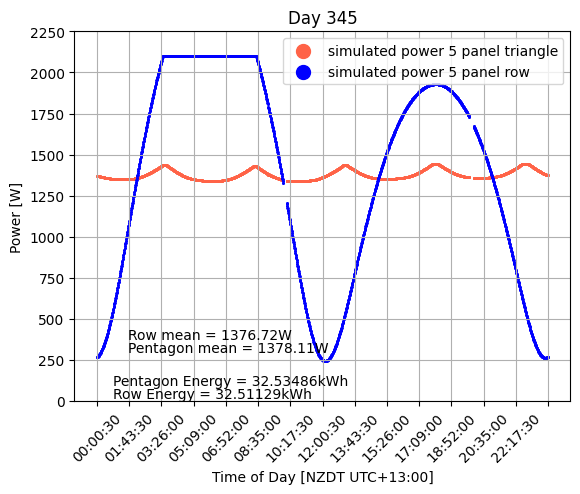

In [22]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50

print(eff_direct)
print(eff_isotropic)


# ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
angle_1 = 0
angle_2 = 72
angle_3 = 72*2
angle_4 = 72*3
angle_5 = 72*4
simulation_101_1 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_1),2)
simulation_101_2 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_2),2)
simulation_101_3 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_3),2)
simulation_101_4 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_4),2)
simulation_101_5 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_5),2)

simulation_101_Pentagon = simulation_101_1 + simulation_101_2 + simulation_101_3 + simulation_101_4 + simulation_101_5
ax1.scatter(time_101, simulation_101_Pentagon, color = 'tomato', s = 1, label = 'simulated power 5 panel triangle')
simulation_101_Row_5 = simulation_101_1*5
ax1.scatter(time_101, simulation_101_Row_5, color = 'blue', s = 1, label = 'simulated power 5 panel row')

# ax1.scatter(time_101, simulation_101_1, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_2, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_3, color = 'tomato', s = 1, label = 'simulated Power_101')

# ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
# ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
# ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
# ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)

# calculate the integrated power (energy) of each array design:

Integrated_Simulation_101_Pentagon = trapezoid(np.nan_to_num(simulation_101_Pentagon,nan = 0),dx=30)
Integrated_Simulation_101_Pentagon_kWh = Integrated_Simulation_101_Pentagon/(1000*60**2)
# print(f'Integrated_Simulation_101_Pentagon_kwh = {Integrated_Simulation_101_Pentagon_kwh}')
plt.text(100, 100, f'Pentagon Energy = {np.round(Integrated_Simulation_101_Pentagon_kWh,5)}kWh')

Integrated_Simulation_101_Row_5 = trapezoid(np.nan_to_num(simulation_101_Row_5,nan = 0),dx=30)
Integrated_Simulation_101_Row_5_kWh = Integrated_Simulation_101_Row_5/(1000*60**2)
# print(f'Integrated_Simulation_101_Pentagon_kwh = {Integrated_Simulation_101_Pentagon_kwh}')
plt.text(100, 20, f'Row Energy = {np.round(Integrated_Simulation_101_Row_5_kWh,5)}kWh')

# Calculate the mean power output:
simulation_Pentagon_mean = np.nanmean(simulation_101_Pentagon)
simulation_row_5_mean = np.nanmean(simulation_101_Row_5)

plt.text(200, 300, f'Pentagon mean = {np.round(simulation_Pentagon_mean,2)}W')

plt.text(200, 380, f'Row mean = {np.round(simulation_row_5_mean,2)}W')


ax1.legend(markerscale = 10)
ax1.set_ylim(0,450*5)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()


0.2272888275093839
0.05707936785663853
[  0.  45.  90. 135. 180. 225. 270. 315.]


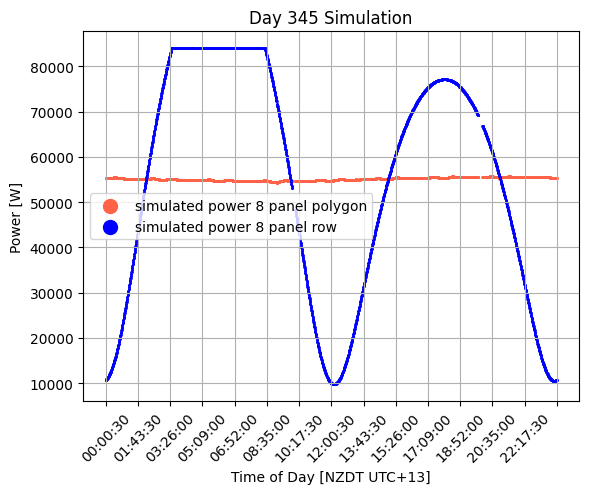

In [29]:
# N panel simulation compairison

number_of_panels = 8
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50

print(eff_direct)
print(eff_isotropic)


# ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13]')
ax1.set_ylabel('Power [W]')

# Generate a list of angles for this polygon
angles_for_polygon = np.linspace(0,360, number_of_panels+1)[:-1]
print(angles_for_polygon)
simulations_at_different_angles = []
for angle_of_polygon in angles_for_polygon:
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle_of_polygon),2)
    simulations_at_different_angles.append(simulation_101)
simulations_at_different_angles = np.array(simulations_at_different_angles)
simulation_101_polygon = 25*simulations_at_different_angles.sum(axis=0)
simulation_101_Row = 25*simulation_101_1*number_of_panels

# print(simulations_at_different_angles)
# print(len(simulation_101_Row))
# print(len(time_101))

ax1.scatter(time_101, simulation_101_polygon, color = 'tomato', s = 1, label = f'simulated power {number_of_panels} panel polygon')
ax1.scatter(time_101, simulation_101_Row, color = 'blue', s = 1, label = f'simulated power {number_of_panels} panel row')

# ax1.scatter(time_101, simulation_101_1, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_2, color = 'tomato', s = 1, label = 'simulated Power_101')
# ax1.scatter(time_101, simulation_101_3, color = 'tomato', s = 1, label = 'simulated Power_101')

# ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
# ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
# ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
# ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)
ax1.legend(markerscale = 10)
# ax1.set_ylim(0,450*number_of_panels)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day} Simulation')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')

# calculate the integrated power (energy) of each array design:

Integrated_Simulation_101_polygon = trapezoid(np.nan_to_num(simulation_101_polygon,nan = 0),dx=30)
Integrated_Simulation_101_polygon_kWh = Integrated_Simulation_101_polygon/(1000*60**2)
# print(f'Integrated_Simulation_101_polygon_kwh = {Integrated_Simulation_101_polygon_kwh}')
# plt.text(100, .1*np.max(simulation_101_Row), f'polygon Energy = {np.round(Integrated_Simulation_101_polygon_kWh,5)}kWh')

Integrated_Simulation_101_Row = trapezoid(np.nan_to_num(simulation_101_Row,nan = 0),dx=30)
Integrated_Simulation_101_Row_kWh = Integrated_Simulation_101_Row/(1000*60**2)
# print(f'Integrated_Simulation_101_polygon_kwh = {Integrated_Simulation_101_polygon_kwh}')
# plt.text(100, .2*np.max(simulation_101_Row), f'Row Energy = {np.round(Integrated_Simulation_101_Row_kWh,5)}kWh')

# Calculate the mean power output:
simulation_polygon_mean = np.nanmean(simulation_101_polygon)
simulation_row_mean = np.nanmean(simulation_101_Row)

# plt.text(200, .7*np.max(simulation_101_Row), f'polygon power mean = {np.round(simulation_polygon_mean,2)}W')

# plt.text(200, .8*np.max(simulation_101_Row), f'Row power mean = {np.round(simulation_row_mean,2)}W')


plt.show()





650.2257531486822


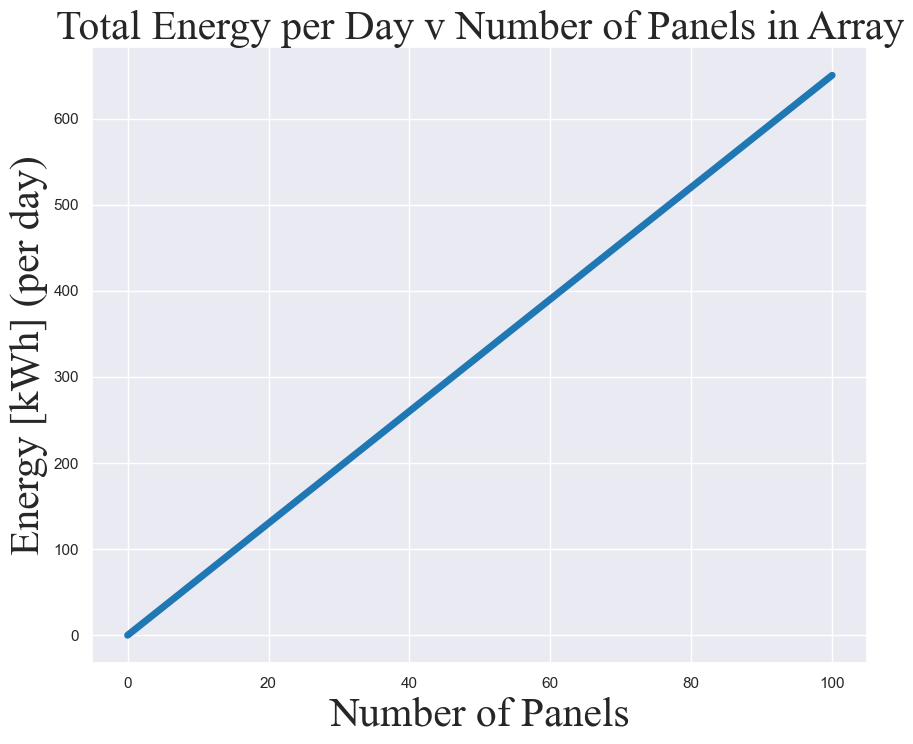

In [112]:
# plot of energy per panel
import seaborn as sns
max_number_of_panels = 100
Energy_for_number = []
for number_of_panels in range(max_number_of_panels+1):
    simulation_101_Row = simulation_101_1*number_of_panels
    Integrated_Simulation_101_Row = trapezoid(np.nan_to_num(simulation_101_Row,nan = 0),dx=30)
    Integrated_Simulation_101_Row_kWh = Integrated_Simulation_101_Row/(1000*60**2)
    Energy_for_number.append(Integrated_Simulation_101_Row_kWh)
print(Energy_for_number[-1])
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(range(max_number_of_panels+1), Energy_for_number, linewidth = 5, color =  'tab:blue')
plt.xlabel('Number of Panels', fontname = 'Times New Roman', fontsize = 30)
plt.ylabel('Energy [kWh] (per day)', fontname = 'Times New Roman', fontsize = 30)
plt.title('Total Energy per Day v Number of Panels in Array', fontname = 'Times New Roman', fontsize = 30)
plt.grid('on')
sns.set_theme(style = 'darkgrid')
plt.show()

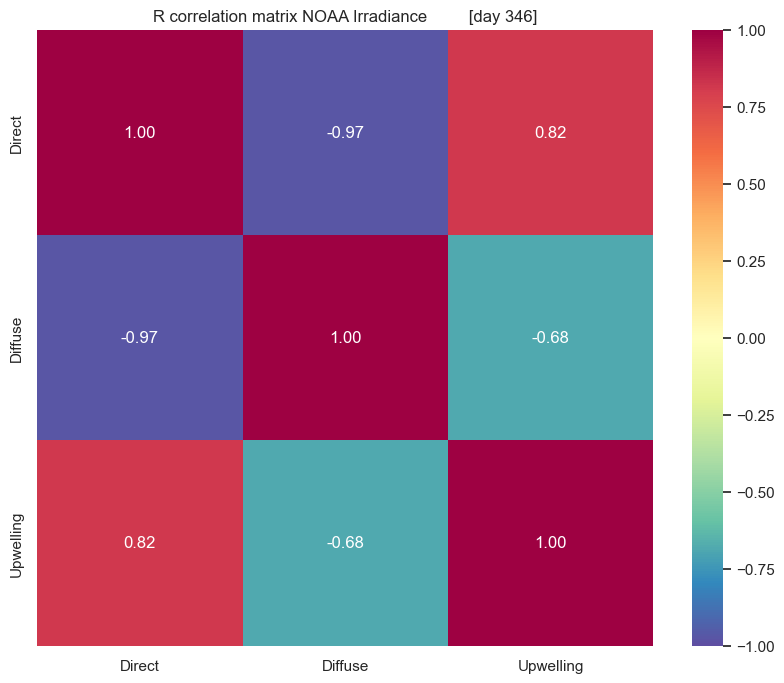

In [50]:
# plt.scatter(np.arange(0,1440,1),Direct_Irradiance, s = 1)
# plt.scatter(np.arange(0,1440,1),Diffuse_Irradiance, s = 1)
# plt.scatter(np.arange(0,1440,1),Upwelling_Irradiance, s = 1)

import seaborn as sns
Irradiance_Data_Frame = pd.DataFrame({'Direct': Direct_Irradiance, 'Diffuse': Diffuse_Irradiance, 'Upwelling': Upwelling_Irradiance})
Corr_Matrix = (Irradiance_Data_Frame.corr()).round(2)
Corr_Matrix.style.background_gradient(cmap = 'Greens')
# pd.plotting.scatter_matrix(Corr_Matrix, figsize = (8,8))
# sns.color_palette("Spectral", as_cmap=True)

Corr_Mask = np.triu(np.ones_like(Corr_Matrix, dtype = bool))
plt.figure(figsize = (10,8))
sns.heatmap(Corr_Matrix, vmin = -1, vmax = 1, annot = True, fmt = '0.2f', square = True, cmap = 'Spectral_r')
plt.title(f'R correlation matrix NOAA Irradiance         [day {day}]')
plt.show()






# Irradiance_Data_Frame = pd.DataFrame({'Direct': Direct_Irradiance, 'Diffuse': Diffuse_Irradiance, 'Upwelling': Upwelling_Irradiance})
# Corr_Matrix = (Irradiance_Data_Frame.corr()).round(2)
# # Corr_Matrix.style.background_gradient(cmap = 'Greens')
# # pd.plotting.scatter_matrix(Corr_Matrix, figsize = (8,8))
# # sns.color_palette("Spectral", as_cmap=True)

# Corr_Mask = np.triu(np.ones_like(Corr_Matrix, dtype = bool))
# plt.figure(figsize = (10,8))
# sns.heatmap(Corr_Matrix, vmin = -1, vmax = 1, annot = True, fmt = '0.2f', square = True, cmap = 'Spectral_r')
# plt.title(f'R**2 correlation matrix NOAA Irradiance         [day {day}]')
# plt.show()




[    6.44645233 -1738.9907845 ]
[[1.         0.81894605]
 [0.81894605 1.        ]]


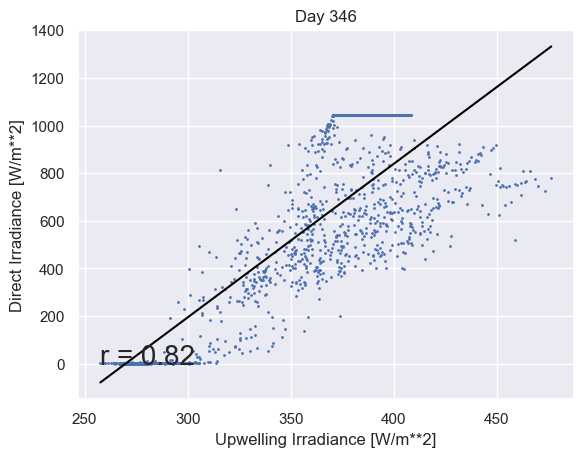

In [51]:
Direct_Power = Direct_Irradiance*eff_direct*area
Diffuse_Power = Diffuse_Irradiance*eff_diffuse*area
Upwelling_Power = Upwelling_Irradiance*eff_upwelling*area

# mask the nan values
irradiance_nan_mask = ~np.isnan(Upwelling_Irradiance)&~np.isnan(Direct_Irradiance)
# print(irradiance_nan_mask)
coeff = np.polyfit(Upwelling_Irradiance[irradiance_nan_mask], Direct_Irradiance[irradiance_nan_mask], deg = 1)
print(coeff)

xvals_for_fit = np.linspace(np.min(Upwelling_Irradiance[irradiance_nan_mask]), np.max(Upwelling_Irradiance[irradiance_nan_mask]), 1000)
best_fit_line = np.poly1d(coeff)

correlation_matrix = np.corrcoef(Upwelling_Irradiance[irradiance_nan_mask], Direct_Irradiance[irradiance_nan_mask])
print(correlation_matrix)
r = correlation_matrix[0,1]
plt.plot(xvals_for_fit, best_fit_line(xvals_for_fit), color = 'black')
plt.scatter(Upwelling_Irradiance, Direct_Irradiance, s = 1)
plt.ylabel('Direct Irradiance [W/m**2]')
plt.xlabel('Upwelling Irradiance [W/m**2]')
# plt.xlim(7.5,20)
# plt.ylim(0,500)
plt.title(f'Day {day}')
plt.text(np.min(Upwelling_Irradiance),np.min(Direct_Irradiance), f'r = {np.round(r,2)}', fontsize = 20)
plt.show()

[  -3.76212713 1311.74722807]
[[ 1.         -0.96936662]
 [-0.96936662  1.        ]]


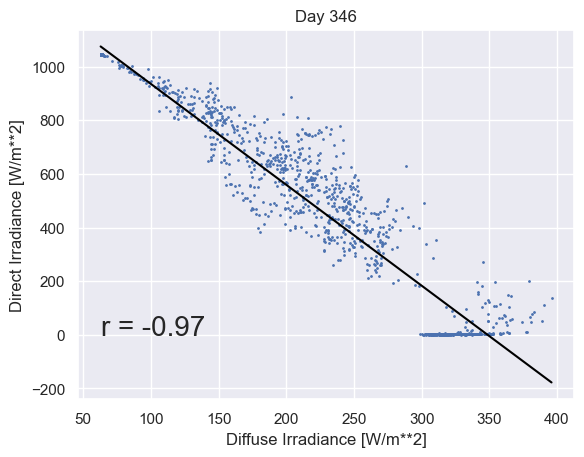

In [52]:
# mask the nan values
irradiance_nan_mask = ~np.isnan(Diffuse_Power)&~np.isnan(Direct_Power)
# print(irradiance_nan_mask)
coeff = np.polyfit(Diffuse_Irradiance[irradiance_nan_mask], Direct_Irradiance[irradiance_nan_mask], deg = 1)
print(coeff)

xvals_for_fit = np.linspace(np.min(Diffuse_Irradiance[irradiance_nan_mask]), np.max(Diffuse_Irradiance[irradiance_nan_mask]), 1000)
best_fit_line = np.poly1d(coeff)
# print(xvals_for_fit)
correlation_matrix = np.corrcoef(Diffuse_Irradiance[irradiance_nan_mask], Direct_Irradiance[irradiance_nan_mask])
print(correlation_matrix)
r = correlation_matrix[0,1]
plt.plot(xvals_for_fit, best_fit_line(xvals_for_fit), color = 'black')
plt.scatter(Diffuse_Irradiance, Direct_Irradiance, s = 1)
plt.ylabel('Direct Irradiance [W/m**2]')
plt.xlabel('Diffuse Irradiance [W/m**2]')
# plt.xlim(7.5,20)
# plt.ylim(0,500)
plt.title(f'Day {day}')
plt.text(np.min(Diffuse_Irradiance), np.min(Direct_Irradiance), f'r = {np.round(r,2)}', fontsize = 20)
plt.show()

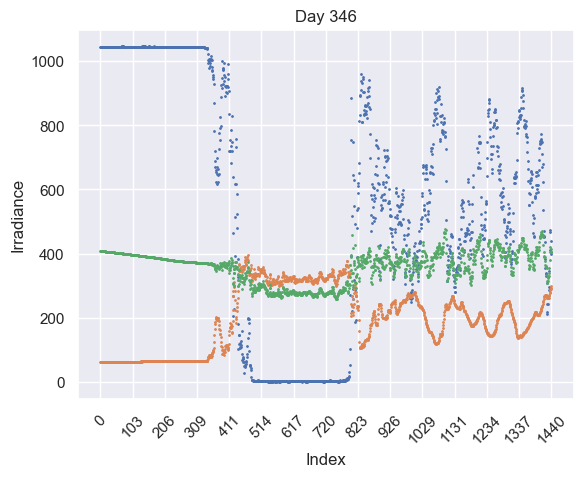

In [54]:
fig, ax1 = plt.subplots()
ax1.scatter(np.linspace(0,1440, 1440),Direct_Irradiance, s = 1)
ax1.scatter(np.linspace(0,1440, 1440),Diffuse_Irradiance, s = 1)
ax1.scatter(np.linspace(0,1440, 1440),Upwelling_Irradiance, s = 1)

ax1.set_xticks(np.linspace(0, 1440, 15))
ax1.set_xlabel(f'Index')
ax1.set_ylabel(f'Irradiance')
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)


97.63974908721322
0.09792323341123638
solved for upwelling irradiance: 0.06
solved for diffuse irradiance: 0.04
0.2164315355252988


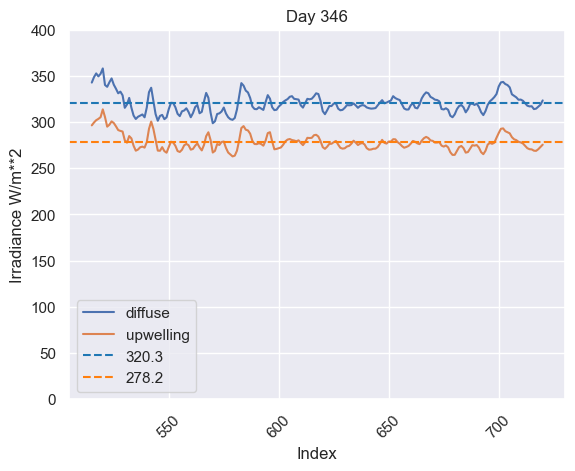

In [93]:
# Lets split the isotropic conversion factor into the upwelling conversion factor and diffuse conversion factor
# Assume up_conv_factor+diffuse_conv_factor = isotropic_conv_factor    **conv_factor = eff**


# Lets consider the part of day 346 where the dirrect irradiance is 0
# This is inbetween indecies 514 and 720 to be safe
start_346_range = 514
stop_346_range = 720
Upwelling_Irradiance_range_346 = Upwelling_Irradiance[start_346_range:stop_346_range]
Diffuse_Irradiance_range_346 = Diffuse_Irradiance[start_346_range:stop_346_range]
Upwelling_Irradiance_range_346_mean = np.mean(Upwelling_Irradiance_range_346)
Diffuse_Irradiance_range_346_mean = np.mean(Diffuse_Irradiance_range_346)


power_101_range_346 = np.nanmean(power_101[2*start_346_range:2*stop_346_range])
# power_101_range_346 = 90

print(power_101_range_346)
print(eff_isotropic)
# Power = Area*(eff_up*Irr_up + ((eff_iso-eff_up)*Irr_diff)) using the assumption
# Solving for eff_up with algebra: 
# eff_up = (power/area - Irr_diff*eff_iso)/(Irr_up - Irr_diff)


eff_up_found = (power_101_range_346/(Area*1.7) - Diffuse_Irradiance_range_346_mean*eff_isotropic)/(Upwelling_Irradiance_range_346_mean - Diffuse_Irradiance_range_346_mean)
print(f'solved for upwelling irradiance: {np.round(eff_up_found, 2)}')
print(f'solved for diffuse irradiance: {np.round(eff_isotropic - eff_up_found, 2)}')

fig, ax1 = plt.subplots()
# ax1.scatter(np.linspace(0,1440, 1440),Direct_Irradiance_range_346, s = 1)
ax1.plot(np.arange(start_346_range,stop_346_range, 1)+1,Diffuse_Irradiance_range_346, label = 'diffuse')
ax1.plot(np.arange(start_346_range,stop_346_range, 1)+1,Upwelling_Irradiance_range_346, label = 'upwelling')
ax1.axhline(y = Diffuse_Irradiance_range_346_mean, linestyle = '--', color = 'tab:blue', label = f'{np.round(Diffuse_Irradiance_range_346_mean, 1)}')
ax1.axhline(y = Upwelling_Irradiance_range_346_mean, linestyle = '--', color = 'tab:orange', label = f'{np.round(Upwelling_Irradiance_range_346_mean, 1)}')
ax1.legend()
# ax1.set_xticks(np.linspace(0, 1440, 15))
ax1.set_xlabel(f'Index')
ax1.set_ylabel(f'Irradiance W/m**2')
ax1.set_title(f'Day {day}')
ax1.set_ylim(0,400)
ax1.tick_params(axis='x', labelrotation=45)


print(eff_direct)


In [27]:
# Now Entering AI HELL
# !!!!!!!
# |||||||
# VVVVVVV

In [28]:
# import matplotlib.pyplot as plt
# from numpy import exp, linspace, pi, random, sign, sin

# from lmfit import create_params, minimize
# from lmfit.printfuncs import report_fit

# print(type(power_101))
# # power_101 = power_101['power_101'].to_numpy(dtype=float)
# def Fit_Model(params, time, power_101 = None):
#     '''
#     wrapping function for model
#     '''
#     # print(params)
#     eff_dir = params['eff_direct']
#     eff_isotropic = params['eff_isotropic']
#     sharpness = params['sharpness']
#     effs = [eff_dir, eff_isotropic]
#     sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), [0.2, 0.05, 0.13], 50)
#     sim_power_2879 = np.repeat(sim_power, 2)[:-1]
#     # print(sim_power)
#     valid_mask = ~np.isnan(power_101) & ~np.isnan(sim_power_2879)

#     # Subtract only the valid elements
#     result = power_101[valid_mask] - sim_power_2879[valid_mask]
#     return result

# time = np.linspace(0, 2879, 2879)
# fit_params = create_params(eff_direct=dict(value=.2, max=1, min=0),
#                            eff_isotropic=dict(value=.08, max=1, min = 0),
#                            sharpness=dict(value=50, max=200., min=0),
#                            )

# out = minimize(Fit_Model, fit_params, args=(time,), kws={'power_101': power_101})
# # print(fit_params)
# fit = Fit_Model(out.params, time, power_101 = power_101)
# print(len(fit))
# # report_fit(out, modelpars=p_true, correl_mode='table')

In [29]:
# plt.plot(time, power_101, 'o', label='data')
# plt.plot(time, fit, label='best fit')
# plt.legend()
# plt.show()

In [30]:
# import numpy as np

# def fill_nan_with_continuity(arr):
#     # Create a copy so we don't modify the original array in place
#     arr_filled = arr.copy()
    
#     # Create an array of indices (0, 1, 2, ..., n-1)
#     indices = np.arange(len(arr_filled))
    
#     # Create a boolean mask of where the NaN values are
#     nan_mask = np.isnan(arr_filled)
    
#     # np.interp(where_we_want_values, where_we_have_indices, where_we_have_values)
#     arr_filled[nan_mask] = np.interp(
#         indices[nan_mask],     # The indices of the NaNs we want to fill
#         indices[~nan_mask],    # The indices of the valid, known numbers
#         arr_filled[~nan_mask]  # The actual valid numbers
#     )
    
#     return arr_filled

# # --- Test Case ---
# nan = np.nan
# array = Direct_Irradiance

# result = fill_nan_with_continuity(array)
# # plt.scatter(time,np.repeat(result,2)[:-1], s = 1)
# plt.scatter(time,np.repeat(Direct_Irradiance,2)[:-1], s = 1)